<a href="https://colab.research.google.com/github/Muskuu1109/ASSIGNMENT-ON-FUNCTION/blob/main/Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.  Explain the properties of the F-distribution.

Properties of the F-distribution
The F-distribution is a probability distribution used primarily in variance analysis. Some key properties include:
- It is positively skewed, meaning it is not symmetric.
- It is non-negative, with values ranging from 0 to infinity.
- Its shape depends on two parameters: degrees of freedom for the numerator and denominator.
- As the degrees of freedom increase, the distribution becomes more symmetrical.




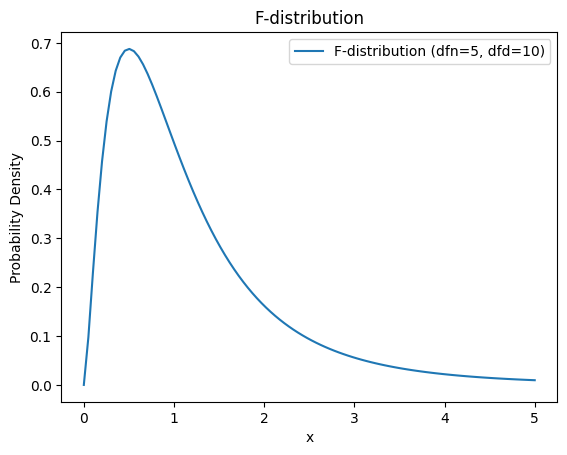

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(0, 5, 100)
dfn, dfd = 5, 10  # Degrees of freedom
pdf = stats.f.pdf(x, dfn, dfd)

plt.plot(x, pdf, label=f'F-distribution (dfn={dfn}, dfd={dfd})')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('F-distribution')
plt.legend()
plt.show()

2. In which types of statistical tests is the F-distribution used, and why is it appropriate for these tests?

Use of the F-distribution in Statistical Tests
The F-distribution is widely used in hypothesis testing, particularly in:
- ANOVA (Analysis of Variance): To compare means across multiple groups.
- F-test for variance comparison: To determine if two samples have equal variances.
- Regression analysis: To test overall model significance.

It is appropriate for these tests because it is designed to compare variance ratios, making it ideal for detecting differences in variability across datasets.



In [2]:
import scipy.stats as stats

# Sample data: Three groups
group1 = [23, 45, 56, 78, 89]
group2 = [34, 48, 58, 62, 85]
group3 = [22, 40, 50, 60, 75]

# One-way ANOVA test
f_statistic, p_value = stats.f_oneway(group1, group2, group3)

print(f'F-statistic: {f_statistic}')
print(f'P-value: {p_value}')

F-statistic: 0.24559220078821825
P-value: 0.7860782104981374


What are the key assumptions required for conducting an F-test to compare the variances of two
populations?

Assumptions for Conducting an F-test
To use an F-test reliably, certain assumptions must be met:
- The samples must be independent.
- The populations must follow a normal distribution.
- The samples should be drawn from populations with equal variance, unless testing for variance differences.
- The data must be quantitative and continuous.



In [3]:
import scipy.stats as stats

# Test for normality using Shapiro-Wilk test
_, p_value_group1 = stats.shapiro(group1)
_, p_value_group2 = stats.shapiro(group2)

print(f'P-value for group1 normality: {p_value_group1}')
print(f'P-value for group2 normality: {p_value_group2}')

P-value for group1 normality: 0.8989039812387174
P-value for group2 normality: 0.9294956283181061


4. What is the purpose of ANOVA, and how does it differ from a t-test?

Purpose of ANOVA vs. t-test
ANOVA (Analysis of Variance) is used to compare three or more group means, whereas a t-test is used to compare only two group means. Key differences:
- ANOVA controls Type I errors better when testing multiple groups.
- T-tests require separate comparisons for multiple groups, which increases error chances.
- ANOVA computes the F-statistic, which examines variation within and between groups.




5. Explain when and why you would use a one-way ANOVA instead of multiple t-tests when comparing more
than two groups.

One-Way ANOVA vs. Multiple t-Tests
Using one-way ANOVA instead of multiple t-tests is beneficial because:
- It prevents increased error rates from repeated comparisons.
- It provides a single test statistic, reducing complexity.
- It shows whether at least one mean differs, but does not specify which groups differ (which requires post-hoc tests).




In [4]:
t_stat1, p_value1 = stats.ttest_ind(group1, group2)
t_stat2, p_value2 = stats.ttest_ind(group2, group3)
t_stat3, p_value3 = stats.ttest_ind(group1, group3)

print(f'T-test between group1 and group2: {p_value1}')
print(f'T-test between group2 and group3: {p_value2}')
print(f'T-test between group1 and group3: {p_value3}')

T-test between group1 and group2: 0.957216683628769
T-test between group2 and group3: 0.5336984240121343
T-test between group1 and group3: 0.5679045131231415


6. Explain how variance is partitioned in ANOVA into between-group variance and within-group variance.
# How does this partitioning contribute to the calculation of the F-statistic?

Partitioning of Variance in ANOVA
ANOVA breaks down variance into:
- Between-group variance: Measures variability among different groups.
- Within-group variance: Measures variability within each group.

The F-statistic is then calculated as: [ F = \frac{\text{Between-group variance}}{\text{Within-group variance}} ] If the between-group variance is significantly higher than within-group variance, it indicates a meaningful difference between groups.


In [12]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Example data
data = {'score': [23, 45, 56, 78, 89, 34, 48, 58, 62, 85, 22, 40, 50, 60, 75],
        'group': ['A']*5 + ['B']*5 + ['C']*5}
df = pd.DataFrame(data)

# Performing ANOVA
model = ols('score ~ group', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

          sum_sq    df         F    PR(>F)
group      236.8   2.0  0.245592  0.786078
Residual  5785.2  12.0       NaN       NaN


7. Compare the classical (frequentist) approach to ANOVA with the Bayesian approach. What are the key differences in terms of how they handle uncertainty, parameter estimation, and hypothesis testing?

Classical vs. Bayesian Approach in ANOVA
The Frequentist (Classical) approach to ANOVA:
- Uses fixed probabilities to test hypotheses.
- Relies on p-values to determine significance.
- Assumes a single true parameter value.

The Bayesian approach:
- Uses probabilistic reasoning for parameter estimation.
- Incorporates prior beliefs into analysis.
- Provides a credible interval instead of relying on p-values.

8. Question: You have two sets of data representing the incomes of two different professions1
V Profession A: [48, 52, 55, 60, 62'
V Profession B: [45, 50, 55, 52, 47] Perform an F-test to determine if the variances of the two professions'
incomes are equal. What are your conclusions based on the F-test?

Task: Use Python to calculate the F-statistic and p-value for the given data.

Objective: Gain experience in performing F-tests and interpreting the results in terms of variance comparison.

In [18]:
import numpy as np
import scipy.stats as stats

# Given data
profession_A = np.array([48, 52, 55, 60, 62])
profession_B = np.array([45, 50, 55, 52, 47])

# Compute variances
var_A = np.var(profession_A, ddof=1)  # Sample variance
var_B = np.var(profession_B, ddof=1)

# Calculate F-statistic
F_statistic = var_A / var_B

# Perform F-test using Levene's test (checks equality of variance)
_, p_value = stats.levene(profession_A, profession_B)

# Output results
print(f'Variance of Profession A: {var_A:.2f}')
print(f'Variance of Profession B: {var_B:.2f}')
print(f'F-statistic: {F_statistic:.2f}')
print(f'P-value: {p_value:.5f}')

# Interpret results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: The variances are significantly different.")
else:
    print("Fail to reject the null hypothesis: The variances are statistically equal.")

Variance of Profession A: 32.80
Variance of Profession B: 15.70
F-statistic: 2.09
P-value: 0.41565
Fail to reject the null hypothesis: The variances are statistically equal.


9. Question: Conduct a one-way ANOVA to test whether there are any statistically significant differences in
average heights between three different regions with the following data1
V Region A: [160, 162, 165, 158, 164'
V Region B: [172, 175, 170, 168, 174'
V Region C: [180, 182, 179, 185, 183'
V Task: Write Python code to perform the one-way ANOVA and interpret the results

V Objective: Learn how to perform one-way ANOVA using Python and interpret F-statistic and p-value.

In [19]:
import scipy.stats as stats

# Heights for three regions
region_A = [160, 162, 165, 158, 164]
region_B = [172, 175, 170, 168, 174]
region_C = [180, 182, 179, 185, 183]

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(region_A, region_B, region_C)

# Output results
print(f'F-statistic: {f_statistic:.2f}')
print(f'P-value: {p_value:.5f}')

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: There is a statistically significant difference in average heights.")
else:
    print("Fail to reject the null hypothesis: No significant difference in average heights between regions.")

F-statistic: 67.87
P-value: 0.00000
Reject the null hypothesis: There is a statistically significant difference in average heights.
